Jupyter started in: C:\Users\Michael Cheng\Documents\DL\image-captioning-comparative\notebooks\notebooks
Found project root at: C:\Users\Michael Cheng\Documents\DL\image-captioning-comparative

--- TENSOR SHAPES ---
Images: torch.Size([4, 3, 224, 224])
Captions: torch.Size([4, 15])

--- TRANSLATED TEXT BATCH ---
Image 1: <START> a woman laying in bed next to a large stuffed animal. <END> <PAD> <PAD>
Image 2: <START> a person with a <UNK> and a roller bag sitting on a bench. <END>
Image 3: <START> a row of urinals in a public bathroom. <END> <PAD> <PAD> <PAD> <PAD> <PAD>
Image 4: <START> a man holding a banana and <UNK> it <END> <PAD> <PAD> <PAD> <PAD> <PAD>


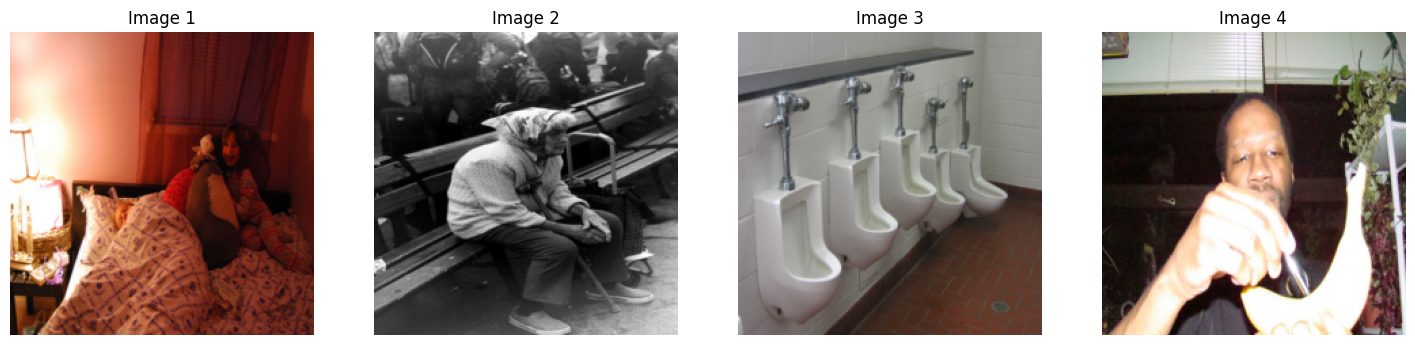

In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os
import torch
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

# misc stuff because I hate juypter notebook 
current_dir = os.getcwd()
print(f"Jupyter started in: {current_dir}")
project_root = current_dir
while not os.path.exists(os.path.join(project_root, 'utils')):
    parent = os.path.dirname(project_root)
    if parent == project_root: 
        raise FileNotFoundError("cant find'utils'!")
    project_root = parent
print(f"Found project root at: {project_root}")
if project_root not in sys.path:
    sys.path.append(project_root)

from utils.dataset import get_loader

# base transform
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop((224, 224)),
    transforms.ToTensor(),
])
data_dir = os.path.join(project_root, 'data') # start dataloader
loader, dataset = get_loader(
    root_dir=os.path.join(data_dir, 'images'), #point to image folder
    ann_file=os.path.join(data_dir, 'annotations', 'dataset_coco.json'),
    split='val', # val split
    transform=transform,
    batch_size=4,
    num_workers=0
)
dataiter = iter(loader) # get one data
images, captions = next(dataiter)
print("\n--- TENSOR SHAPES ---")
print(f"Images: {images.shape}") 
print(f"Captions: {captions.shape}\n") 
print("--- TRANSLATED TEXT BATCH ---") # show it 
for i in range(captions.shape[0]):
    words = [dataset.vocab.itos.get(token.item(), "<UNK>") for token in captions[i]]
    sentence = " ".join(words)
    print(f"Image {i+1}: {sentence}")
fig, axes = plt.subplots(1, 4, figsize=(18, 5)) # plot images
for i in range(images.shape[0]):
    img_for_plot = images[i].permute(1, 2, 0).numpy()
    axes[i].imshow(img_for_plot)
    axes[i].axis("off")
    axes[i].set_title(f"Image {i+1}")
plt.show()